In [2]:
import numpy as np
import finufft
import matplotlib.pyplot as pl

pi = np.pi

In [3]:
class Resampler(object):
    """ Resample a timeseries and computes its FFT

    Example usage:

        TBD

    Attributes
    ----------
    TBD : 
    """
    def __init__(self, **kwws) -> None:
        self.timeseries = {}
        self.resampled_time = {}
        self.spectra = {}
    
    def nufft(self):
        signal = self.timeseries
        tau = self.resampled_time
        bin_no = len(tau) # make it an input
        
        scale = abs((2*np.pi) / (tau[-1] - tau[0]))
        tau_scaled = scale * (tau-tau[0]) - np.pi
        bins = np.arange(bin_no) - bin_no//2
        freqs = bins * scale
        
        weights = finufft.nufft1d1(tau_scaled, signal.astype(complex), bin_no)
        return freqs, weights

    def nufft_real(self):
        signal = self.timeseries
        tau = self.resampled_time
        assert np.isrealobj(signal), "Timeseries is not real"

        scale = abs((2*np.pi) / (tau[-1] - tau[0]))
        tau_scaled = scale * (tau-tau[0]) - np.pi
        
        Nf = len(tau)//2
        N0 = Nf // 2
        bins = np.arange(Nf) # no negative frequencies
        freqs = bins * scale
        signal_shifted = signal * np.exp(1j * N0 * tau_scaled)

        weights = finufft.nufft1d1(tau_scaled, signal_shifted, Nf)
        return freqs, weights

## Monochromatic signal

In [4]:
t = np.linspace(4*pi,6*pi, int(2**15))
f0 = 20 # rad/s
phi = f0*t
signal = np.real(1*np.exp(-1j*phi))

(10.0, 30.0)

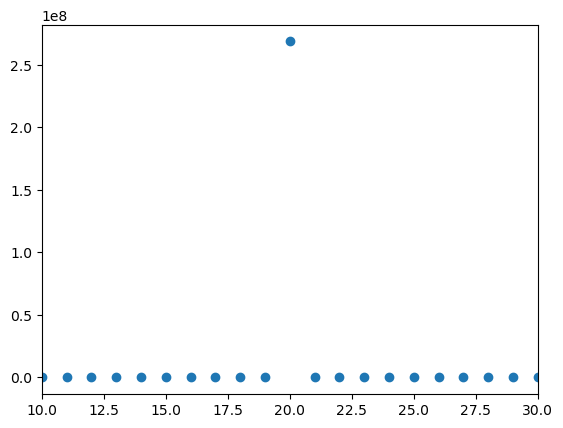

In [5]:
resampler = Resampler()
resampler.timeseries = signal
resampler.resampled_time = t
freqs, weights = resampler.nufft()
pl.plot(freqs, abs(weights)**2, 'o')
pl.xlim(f0 - 10, f0 + 10)

(10.0, 30.0)

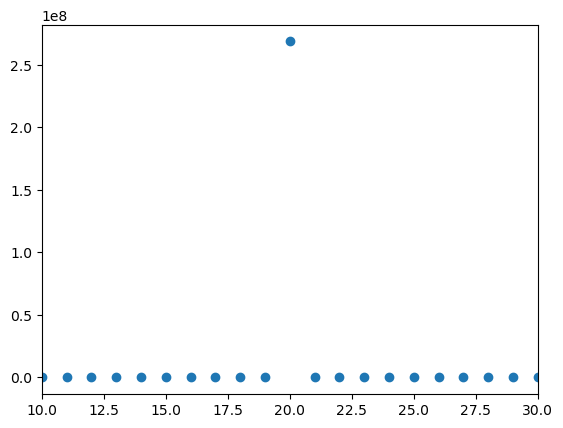

In [6]:
freqs, weights = resampler.nufft_real()
pl.plot(freqs, abs(weights)**2, 'o')
pl.xlim(f0 - 10, f0 + 10)

## With $\dot{f}$

In [7]:
t = np.linspace(0*pi,16*pi, 2**15)
f0 = 21 # rad/s
fdot = 1e0 # rad/s^2 
phi = f0*t+fdot*t**2
signal = np.real(1*np.exp(-1j*phi))
tau = t*(1+fdot/f0*t)

(11.0, 31.0)

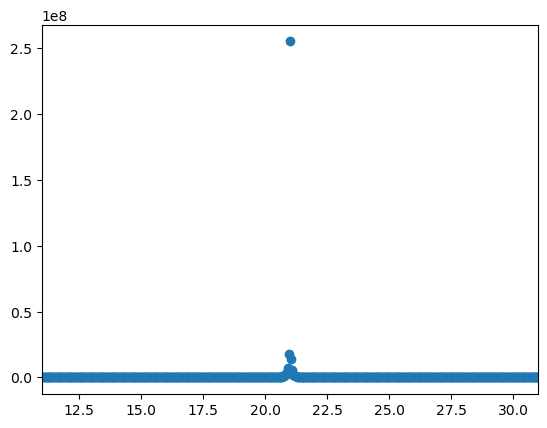

In [8]:
resampler = Resampler()
resampler.timeseries = signal
resampler.resampled_time = tau
freqs, weights = resampler.nufft_real()
pl.plot(freqs, abs(weights)**2, 'o')
pl.xlim(f0 - 10, f0 + 10)

0.004562259244714539


Text(0, 0.5, 'Phase')

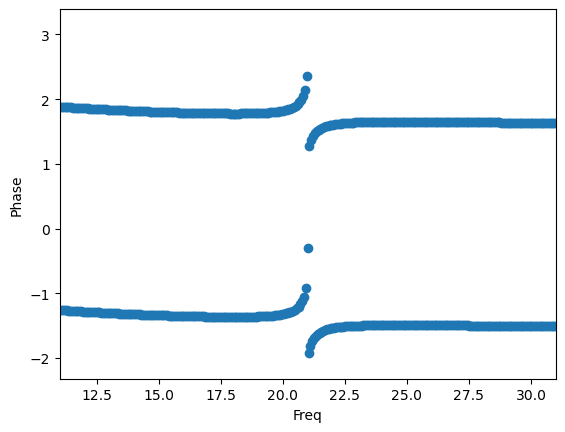

In [9]:
# The spectral leakage is because of bin misalignment
print(min(abs(freqs - f0)))

pl.plot(freqs, np.angle(weights), 'o')
pl.xlim(f0 - 10, f0 + 10)
pl.xlabel("Freq")
pl.ylabel("Phase")

## beta

In [15]:
c = 3e8
G = 6.67e-11
pi = np.pi
const = 96/5*pi**(8/3)*(G/c**3)**(5/3)

f0 = 2**3
Mc = 3e-2* 2e30
f_max = 2**6
T_obs = 2**10
# pad_len = int(340*T_obs) #~0.01 added length to resampled data
beta = const*f0**(8/3)*Mc**(5/3)
f_signal = 4*f_max
nt = round(f_signal*T_obs)
t = (np.arange(nt)/f_signal)
f_ratio = 25

phi = 6*np.pi/5*f0*(1-8./3.*(beta)*t)**(5/8)/beta
tau = 6*np.pi/5*(1-8/3*beta*t)**(5/8)/beta
signal = np.real(1*np.exp(-1j*phi))

(7.95, 8.05)

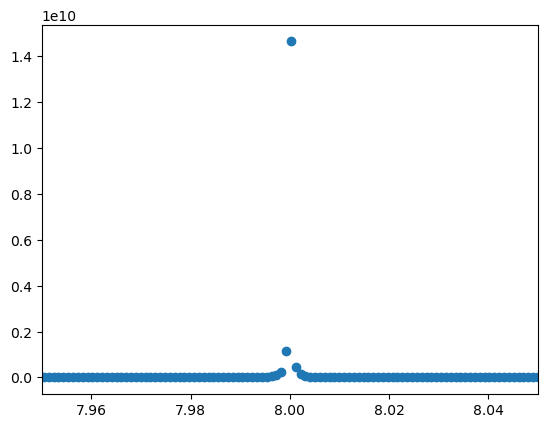

In [16]:
resampler = Resampler()
resampler.timeseries = signal
resampler.resampled_time = tau
freqs, weights = resampler.nufft_real()
pl.plot(freqs, abs(weights)**2, 'o')
pl.xlim(f0 - 0.05, f0 + 0.05)

In [12]:
%timeit resampler.nufft_real()

57.8 ms ± 3.26 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [13]:
%timeit resampler.nufft()

65.2 ms ± 8.84 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


## With error

In [28]:
c = 3e8
G = 6.67e-11
pi = np.pi
const = 96/5*pi**(8/3)*(G/c**3)**(5/3)

f0 = 20
Mc = 3e-2* 2e30
f_max = 200
T_obs = 1e3
# pad_len = int(340*T_obs) #~0.01 added length to resampled data
beta = const*f0**(8/3)*Mc**(5/3)
f_signal = 5*f_max
nt = round(f_signal*T_obs)
t = (np.arange(nt)/f_signal).astype(np.longdouble)
f_ratio = 25

phi = -6*pi/5*f0*(1-8./3.*(beta)*t)**(5/8)/beta
phi = np.mod(phi,2*pi)
signal = 1*np.exp(1j*phi)

In [37]:
offset_percent = 1e-1

tau = -3/5*(1-8/3*(1+offset_percent)*beta*t)**(5/8)/((1+offset_percent)*beta)
scale = (2*pi)/(tau[-1]-tau[0])
tau *= scale
start_diff = -pi-tau[0]
tau += start_diff

Maximum power at f = -20052.00


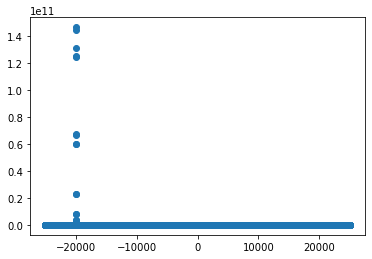

In [38]:
bin_no = int(len(signal)/20)
bins = np.arange(bin_no) - bin_no//2

f = finufft.nufft1d1(tau.astype(np.float64), signal.astype(complex), bin_no)
pl.plot(bins, abs(f)**2, 'o')
# pl.xlim(-20050 - 200, -20050 +200)
found = bins[np.argmax(abs(f)**2)]
print('Maximum power at f = %.2f' % (found))

## Need to check if this aligns with analytical expectations